In [3]:
import numpy as np
import netket as nk
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
def ED(handle, k=5, which="SA"):
    hi = H.hilbert
    if hi.n_states>1e3: #sparse matrix
        sp_h = H.to_sparse()
        eig_vals, eig_vecs = eigsh(sp_h, k=k, which=which)
        sort_idx = np.argsort(eig_vals)
        eig_vals_sorted = eig_vals[sort_idx]
        eig_vecs_sorted = eig_vecs[:, sort_idx]
    else:
        eig_vals_sorted, eig_vecs_sorted = np.linalg.eigh(H.to_dense())
    E0 = np.min(eig_vals_sorted)
    degeneracy = np.sum(np.abs(eig_vals_sorted - E0) < 1e-8)
    return eig_vals_sorted, eig_vecs_sorted, degeneracy

In [102]:
# Parameters
L = 24
t1 = 1.0  # fixed
ratios = np.linspace(0.1, 2.0, 60)  # t2/t1 values to sweep
# Graph and Hilbert space
graph =  nk.graph.Chain(length=L,pbc=False)
hi = nk.hilbert.SpinOrbitalFermions(graph.n_nodes,n_fermions=1,s=None)
# Store eigenvalues for plotting
spectra = []
for r in ratios:
    t2 = r * t1
    H = 0
    for i in range(L - 1):
        t = t2 if i % 2 == 0 else t1
        H += -t * (cdag(hi,i) * c(hi,i+1) + cdag(hi,i+1) * c(hi,i))
    # Solve for all eigenvalue
    eigvals, eigvecs,_= ED(H)
    spectra.append(np.sort(eigvals))  # sort eigenvalues for plotting
spectra = np.array(spectra)

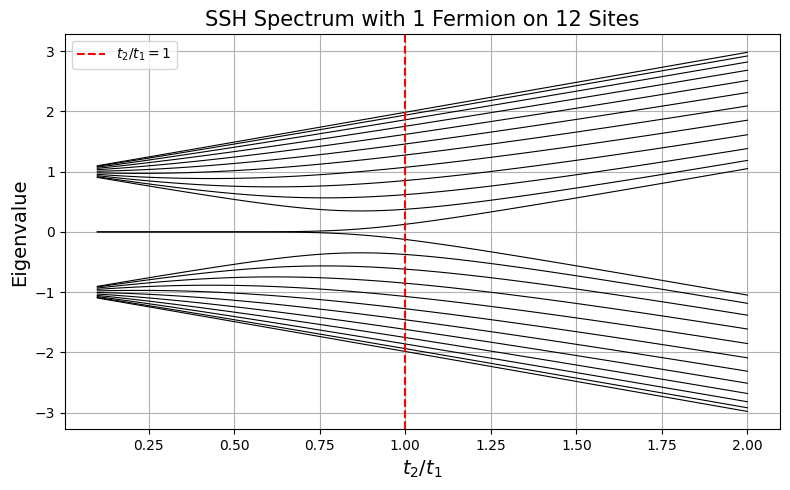

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Loop over each eigenvalue index (one line per band)
for i in range(spectra.shape[1]):
    plt.plot(ratios, spectra[:, i], color='black', lw=0.8)

plt.axvline(1.0, color='red', linestyle='--', label='$t_2/t_1 = 1$')
plt.xlabel('$t_2 / t_1$', fontsize=14)
plt.ylabel('Eigenvalue', fontsize=14)
plt.title('SSH Spectrum with 1 Fermion on 12 Sites', fontsize=15)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


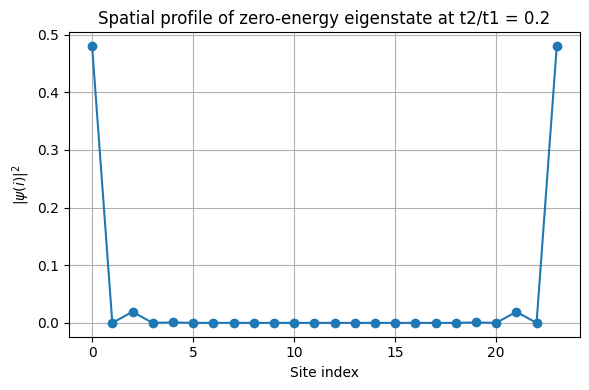

In [ ]:
t1,t2=1.,0.2
H = 0
for i in range(L - 1):
    t = t2 if i % 2 == 0 else t1
    H += -t * (cdag(hi,i) * c(hi,i+1) + cdag(hi,i+1) * c(hi,i))
# Solve for all eigenvalue
eigvals, eigvecs,_= ED(H)

zero_idx = np.argmin(np.abs(eigvals))     # Index of energy closest to zero
psi_zero = eigvecs[:, zero_idx]           # Corresponding eigenvector
prob_density = np.abs(psi_zero)**2
plt.figure(figsize=(6, 4))
plt.plot(range(len(prob_density)), prob_density, 'o-')
plt.xlabel("Site index")
plt.ylabel(r"$|\psi(i)|^2$")
plt.title(f"Spatial profile of zero-energy eigenstate at t2/t1 = {t2/t1}")
plt.grid(True)
plt.tight_layout()
plt.show()